In [2]:
!pip list

Package                       Version
----------------------------- -----------
aiohappyeyeballs              2.4.4
aiohttp                       3.11.10
aiosignal                     1.2.0
alabaster                     0.7.16
annotated-types               0.7.0
anyio                         4.9.0
apeye                         1.4.1
apeye-core                    1.1.5
arrow                         1.3.0
astroid                       3.3.8
asttokens                     3.0.0
asyncssh                      2.17.0
atomicwrites                  1.4.0
attrs                         24.3.0
autopep8                      2.0.4
babel                         2.16.0
beautifulsoup4                4.12.3
binaryornot                   0.4.4
black                         24.10.0
bleach                        6.2.0
Brotli                        1.0.9
certifi                       2025.1.31
cffi                          1.17.1
chardet                       4.0.0
charset-normalizer            3.3.2
click 

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
data_df=pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [10]:
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [12]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [14]:
data_df.isnull().sum

<bound method DataFrame.sum of        age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    False    False                     False     False              False   
1    False    False                     False     False              False   
2    False    False                     False     False              False   
3    False    False                     False     False              False   
4    False    False                     False     False              False   
..     ...      ...                       ...       ...                ...   
294  False    False                     False     False              False   
295  False    False                     False     False              False   
296  False    False                     False     False              False   
297  False    False                     False     False              False   
298  False    False                     False     False              False   

     high_blood_pressure  platel

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\1138870773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)


[Text(0, 0, '203')]

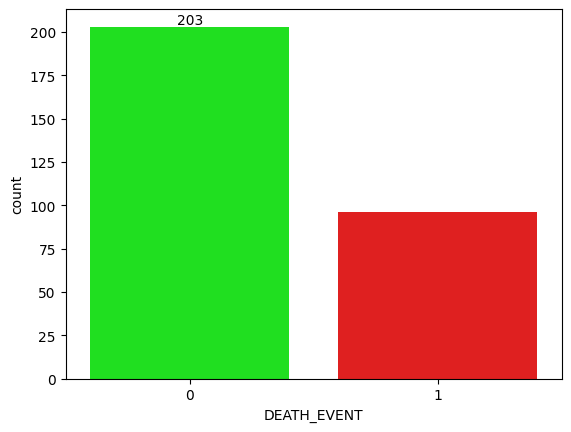

In [16]:
cols=["#00FF00","#FF0000"]
ax=sns.countplot(x=data_df["DEATH_EVENT"],palette=cols)
ax.bar_label(ax.containers[0])

In [18]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


<Axes: >

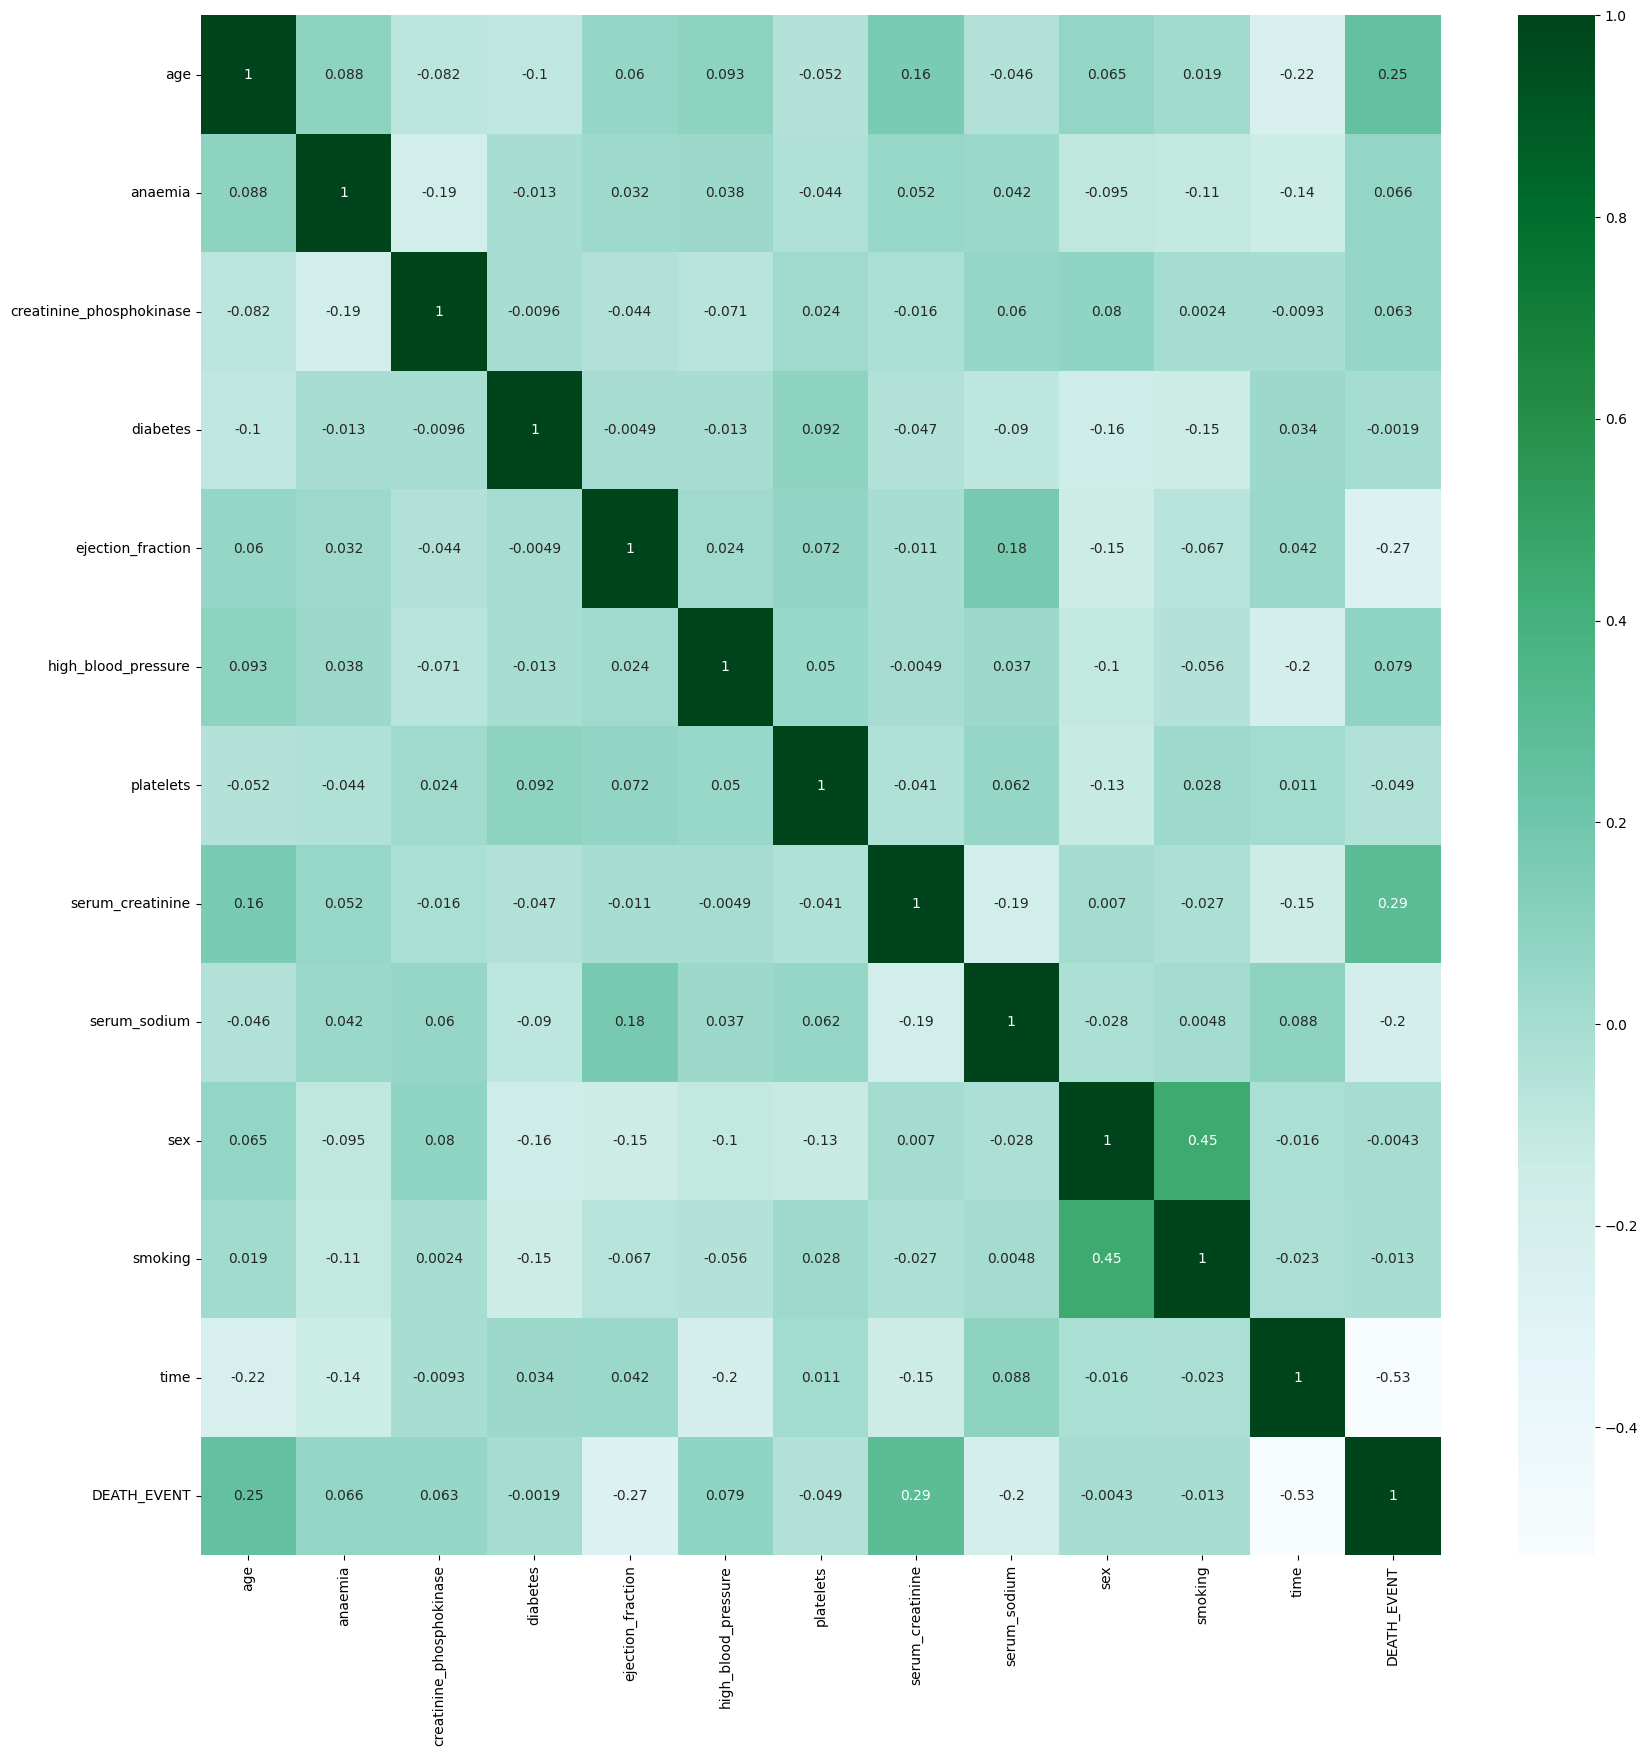

In [20]:
plt.subplots(figsize=(20,20))
sns.heatmap(data_df.corr(),cmap="BuGn",annot=True)

<Axes: xlabel='age', ylabel='count'>

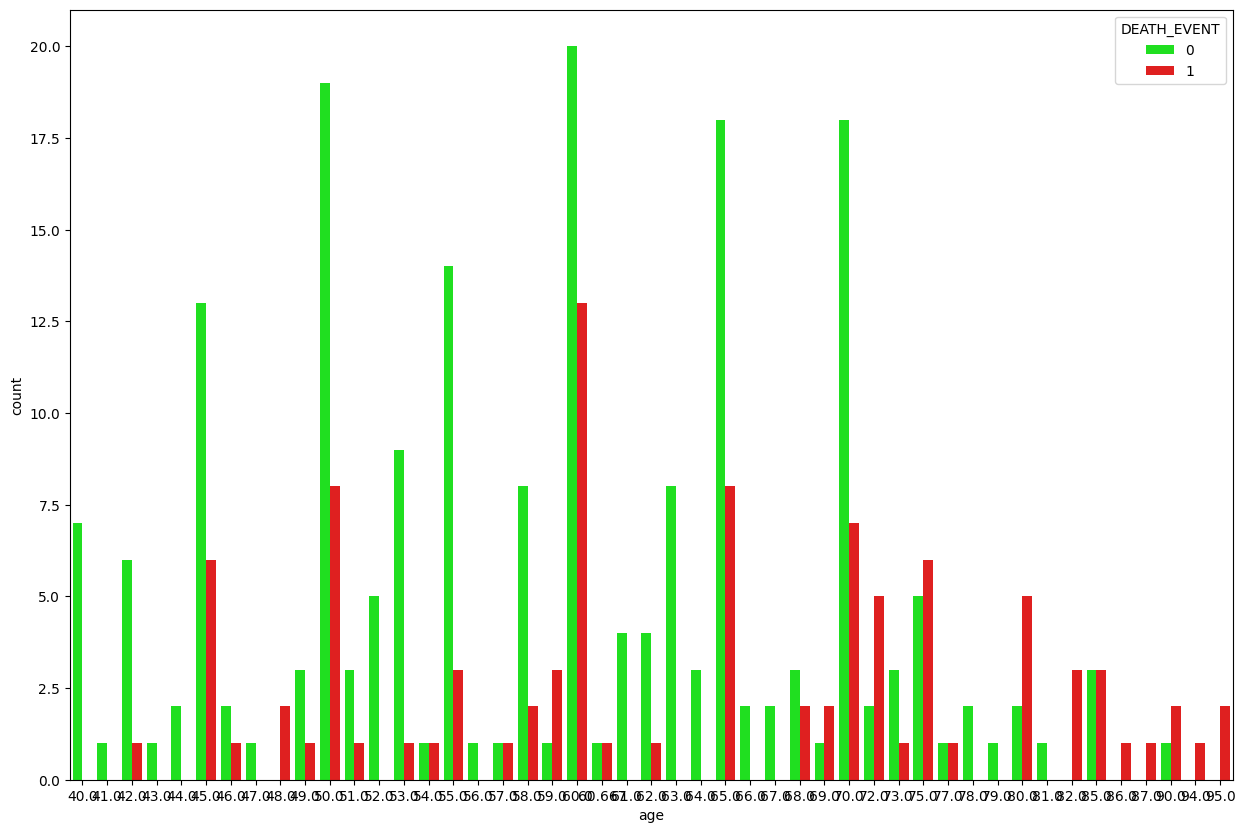

In [21]:
plt.figure(figsize=(15,10))
sns.countplot(x=data_df["age"],data=data_df,hue="DEATH_EVENT",palette=cols)

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)


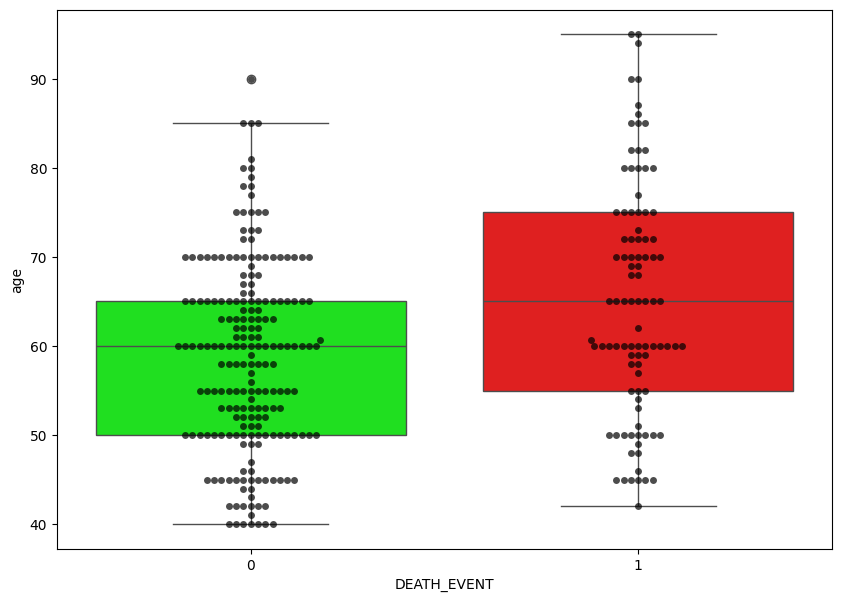

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)
C:\Users\Thakur Sawan Singh\anaconda3\envs\MachineLearning\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


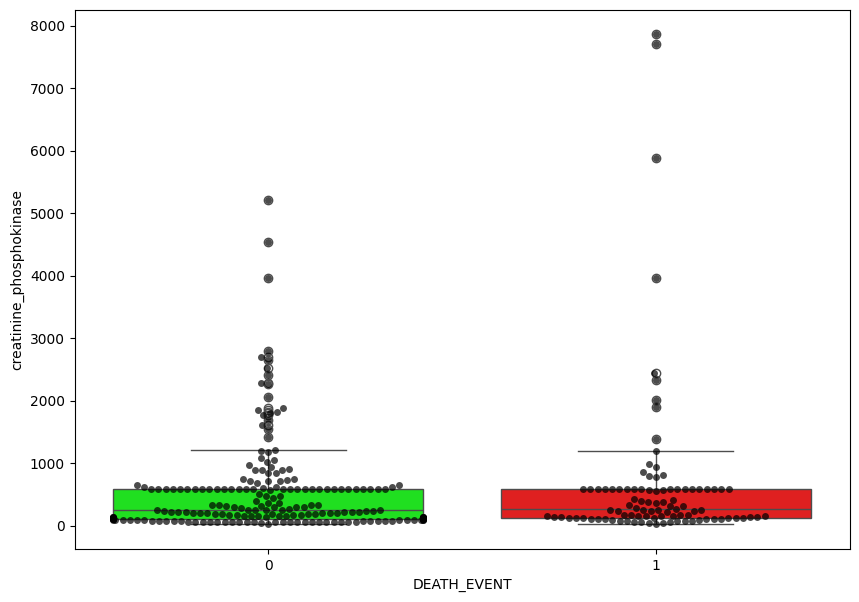

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)


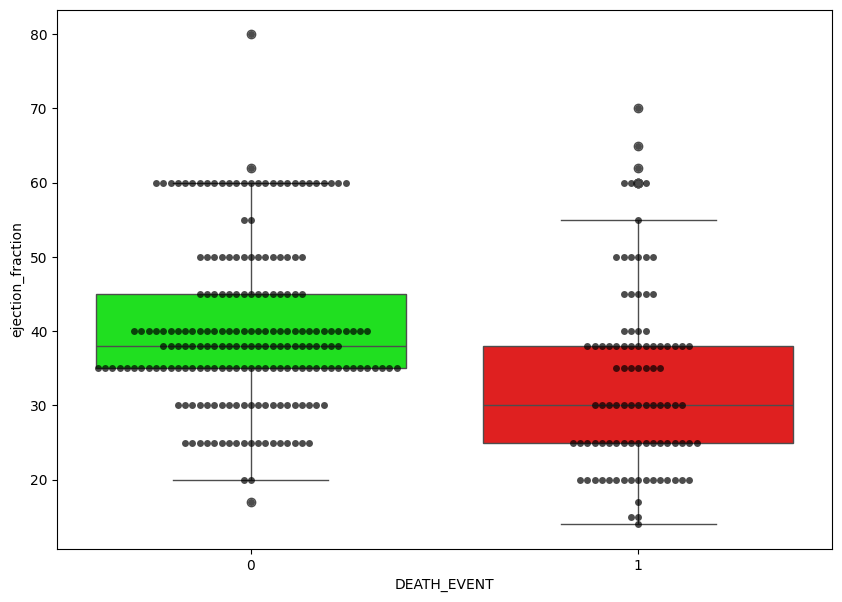

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)


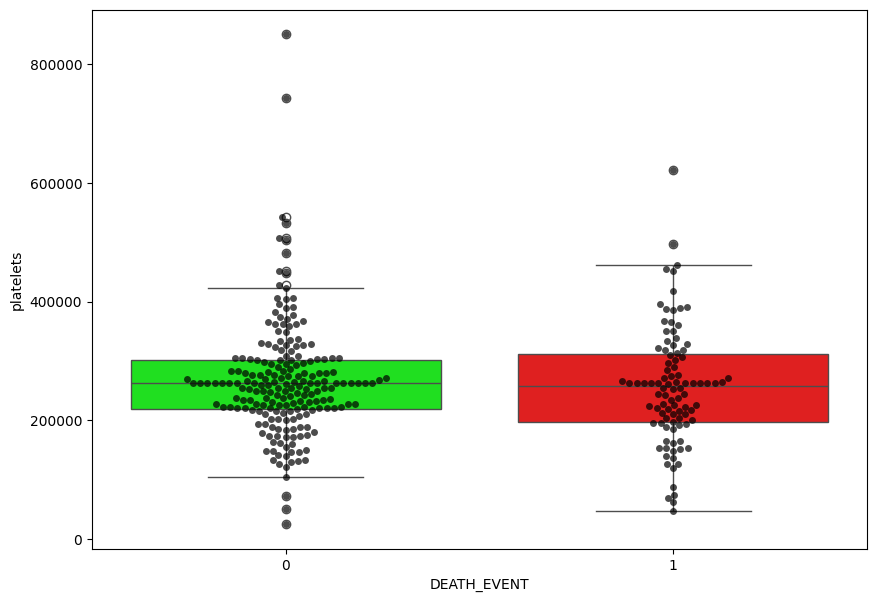

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)
C:\Users\Thakur Sawan Singh\anaconda3\envs\MachineLearning\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


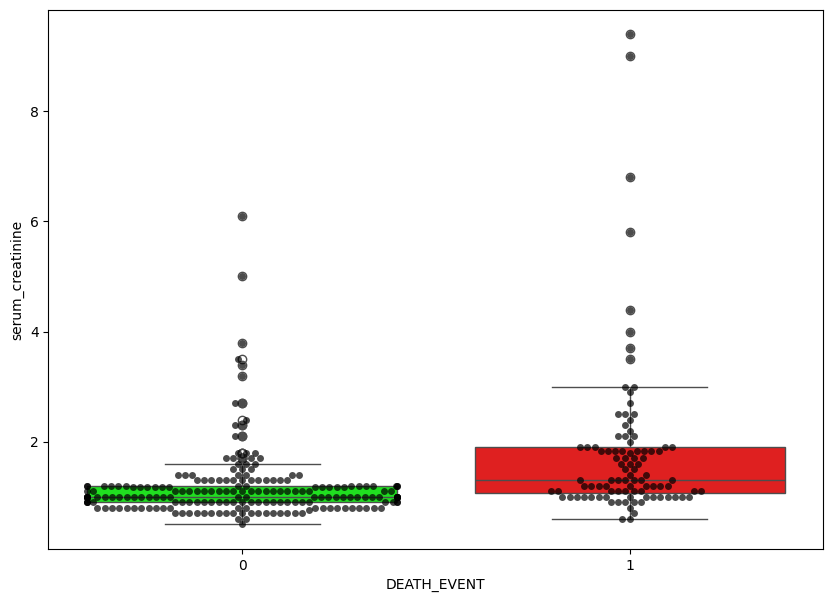

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)


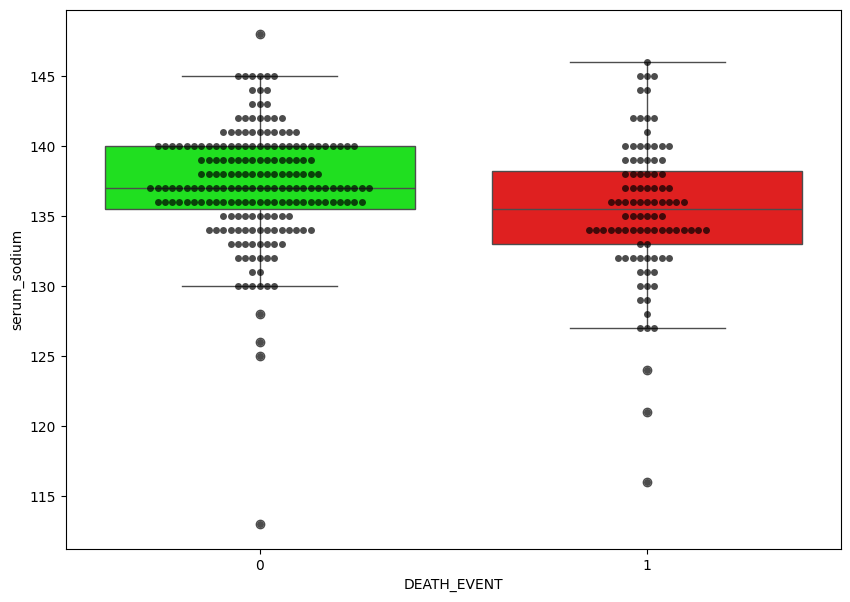

C:\Users\Thakur Sawan Singh\AppData\Local\Temp\ipykernel_2756\2387119518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)


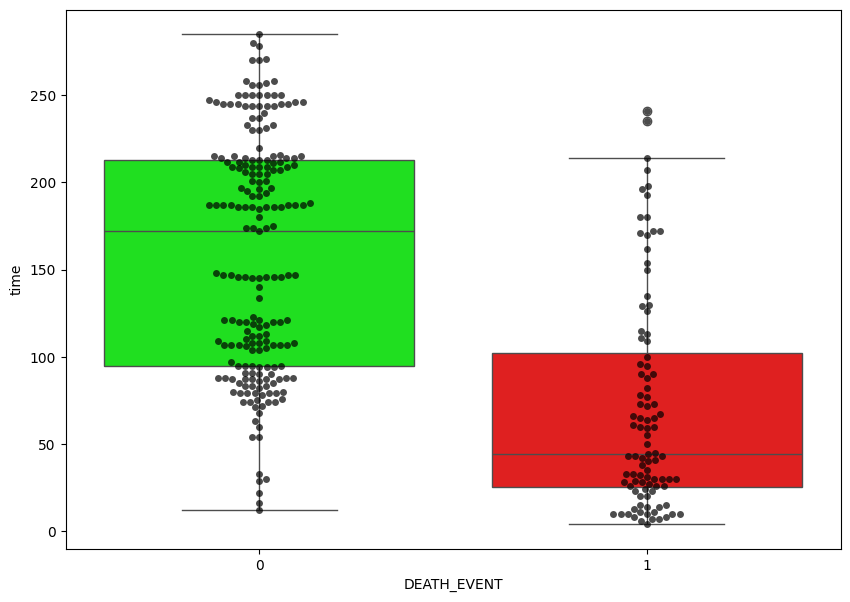

In [23]:
features = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets",
            "serum_creatinine", "serum_sodium", "time"]

for feature in features:
    plt.figure(figsize=(10, 7))
    sns.swarmplot(x=data_df["DEATH_EVENT"], y=data_df[feature], color="black", alpha=0.7)
    sns.boxplot(x=data_df["DEATH_EVENT"], y=data_df[feature], palette=cols)
    plt.show()


In [25]:

X = data_df.drop(["DEATH_EVENT"], axis=1)
y = data_df["DEATH_EVENT"]


col_name = list(X.columns)


ss = StandardScaler()
X_scaled = ss.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_name)


X_scaled.describe().T


,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


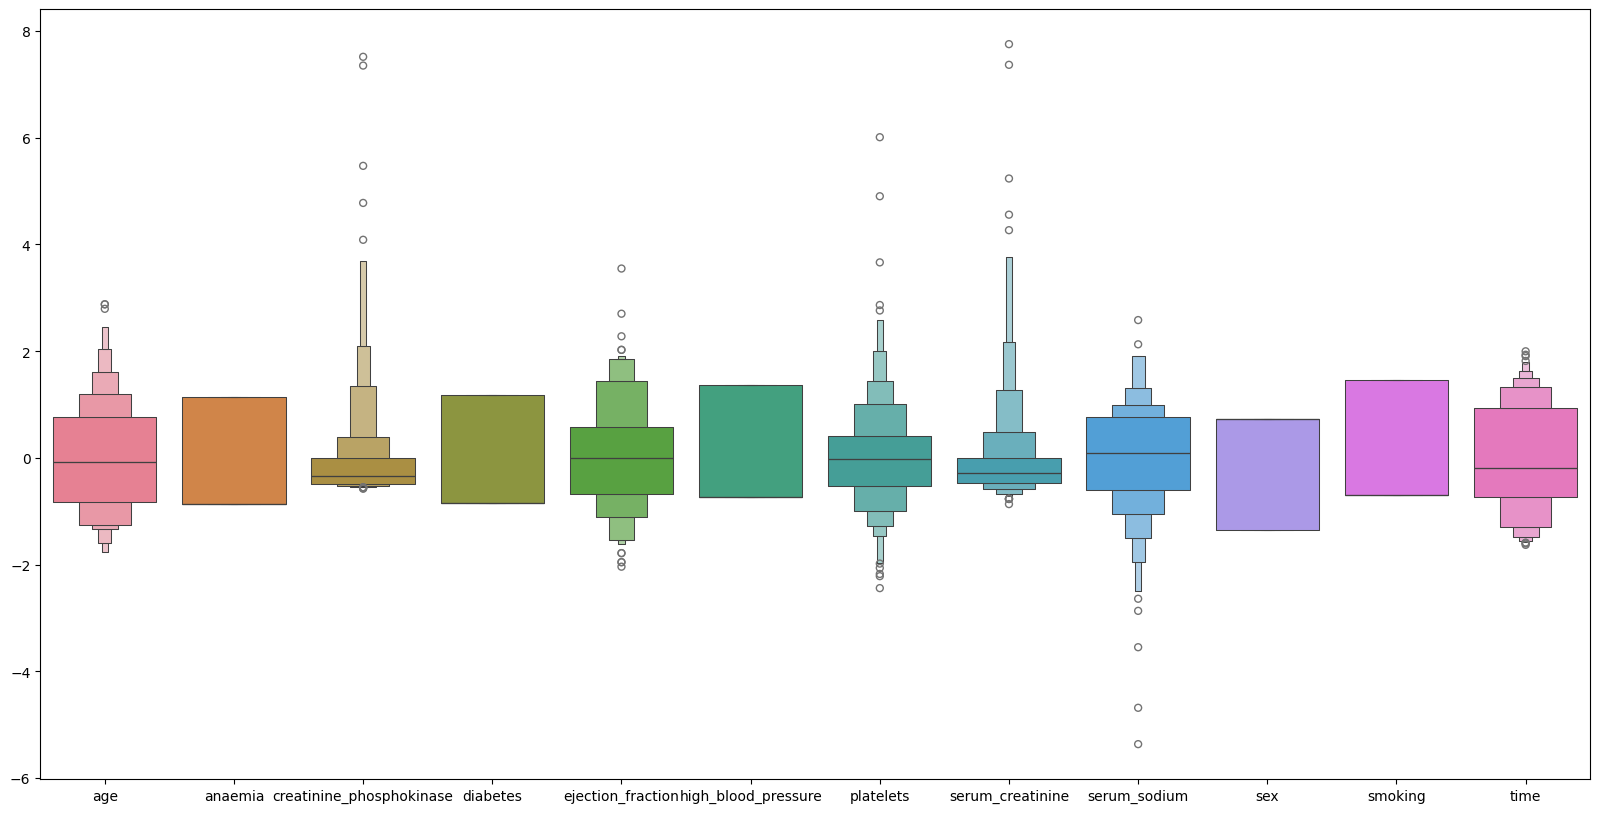

In [26]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)



In [39]:
!pip install tensorflow


  Using cached tensorflow-2.19.0-cp312-cp312-win_amd64.whl.metadata (4.1 kB)
  Using cached absl_py-2.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.5-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached grpcio-1.73.1-cp312-cp312-win_amd64.whl.metadata (4.0 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.10.0-py3-none-any.whl.metadata (6.0 kB)
  Using cached numpy-2.1.3-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached h5

  You can safely remove it manually.
  You can safely remove it manually.


In [41]:
from sklearn.svm import SVC
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import classification_report

model1 = SVC()



In [43]:
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       0.76      0.91      0.83        58
           1       0.75      0.47      0.58        32

    accuracy                           0.76        90
   macro avg       0.75      0.69      0.70        90
weighted avg       0.75      0.76      0.74        90



In [53]:
early_stopping = callbacks.EarlyStopping(min_delta=0.001, patience=20, restore_best_weights=True)

model = Sequential()

model.add(Dense(units=16, kernel_initializer='uniform', activation='relu', input_dim=12))
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid'))



C:\Users\Thakur Sawan Singh\anaconda3\envs\MachineLearning\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history=model.fit(X_train,y_train,batch_size=25,epochs=150,callbacks=[early_stopping],validation_split=0.20)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5913 - loss: 0.6927 - val_accuracy: 0.7619 - val_loss: 0.6906
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6990 - loss: 0.6908 - val_accuracy: 0.7619 - val_loss: 0.6883
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6642 - loss: 0.6899 - val_accuracy: 0.7619 - val_loss: 0.6860
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6512 - loss: 0.6887 - val_accuracy: 0.7619 - val_loss: 0.6838
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6695 - loss: 0.6868 - val_accuracy: 0.7619 - val_loss: 0.6814
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6483 - loss: 0.6855 - val_accuracy: 0.7619 - val_loss: 0.6791
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6647 - loss: 0.6838 - val_accuracy: 0.7619 - val_loss: 0.6765
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6742 - loss: 0.6818 - val_accuracy: 0.7619 - val_loss:

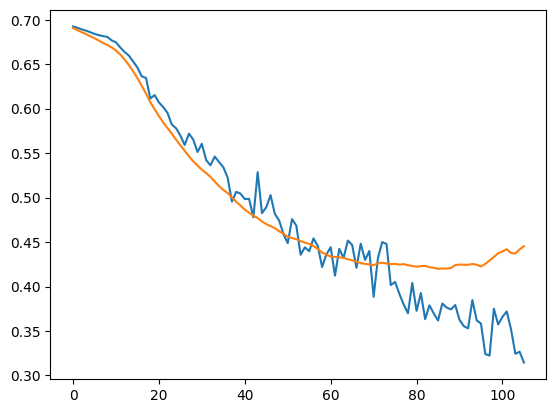

In [61]:
history_df=pd.DataFrame(history.history)

plt.plot(history_df.loc[:,['loss']],label="Training Loss")
plt.plot(history_df.loc[:,['val_loss']],label="Validation Loss")

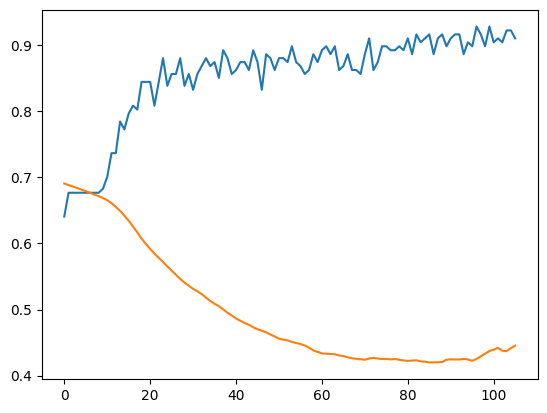

In [63]:
history_df=pd.DataFrame(history.history)

plt.plot(history_df.loc[:,['accuracy']],label="Training Loss")
plt.plot(history_df.loc[:,['val_loss']],label="Validation Loss")

In [65]:
y_pred=model.predict(X_test)
y_pred=(y_pred) > 0.5
print(classification_report(y_test,y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step 
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        58
           1       0.79      0.59      0.68        32

    accuracy                           0.80        90
   macro avg       0.80      0.75      0.77        90
weighted avg       0.80      0.80      0.79        90

